<h1 style="color:#FFFFFF; background-color:#0F172A; text-align:center; font-weight:700; padding:20px 14px; border-radius:10px; margin-bottom:6px; font-size:26px;">Week 7 &mdash; Day 1: Sprint 2 Planning &amp; Convolutional Neural Networks</h1>
<p style="color:#E2E8F0; background-color:#1E293B; text-align:center; font-weight:600; font-style:italic; padding:8px 12px; border-radius:6px; margin-top:0; font-size:15px;">Skin Lesion Classification (Benign vs. Malignant) &mdash; Phase 3 Capstone, Sprint 2 Kickoff</p>

<a id="toc"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">Table of Contents</h2>
<div style="border:1px solid #CBD5E1; padding:16px 26px; border-radius:8px; background-color:#F8FAFC;">
<ol style="font-weight:600; line-height:2.0; color:#0F172A;">
<li><a href="#section0" style="color:#1E40AF; text-decoration:none;">0. Setup</a></li>
<li><a href="#section1" style="color:#1E40AF; text-decoration:none;">1. Learning Objectives</a></li>
<li><a href="#section2" style="color:#1E40AF; text-decoration:none;">2. Beginner Background</a></li>
<li><a href="#section3" style="color:#1E40AF; text-decoration:none;">3. Dataset Setup</a></li>
<li><a href="#section4" style="color:#1E40AF; text-decoration:none;">4. Sprint 2 Planning</a></li>
<li><a href="#section5" style="color:#1E40AF; text-decoration:none;">5. Why Dense Networks Struggle with Images</a></li>
<li><a href="#section6" style="color:#1E40AF; text-decoration:none;">6. Convolution Basics</a></li>
<li><a href="#section7" style="color:#1E40AF; text-decoration:none;">7. Edge Detection Demo</a></li>
<li><a href="#section8" style="color:#1E40AF; text-decoration:none;">8. Parameter Sharing &amp; Why Convolution Is Efficient</a></li>
<li><a href="#section9" style="color:#1E40AF; text-decoration:none;">9. Feature Hierarchy</a></li>
<li><a href="#section10" style="color:#1E40AF; text-decoration:none;">10. Architecture Decision</a></li>
<li><a href="#section11" style="color:#1E40AF; text-decoration:none;">11. Summary</a></li>
</ol>
</div>

<a id="section0"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">0. Setup</h2>
Standard imports, plus a fixed random seed so results don't change between runs. This notebook stays in plain NumPy on purpose &mdash; the goal today is to see exactly what a convolution does. Day 2 rebuilds the same idea as a proper Keras CNN.

In [1]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("NumPy version:", np.__version__)
print("Random seed fixed at:", RANDOM_SEED)

NumPy version: 2.3.5
Random seed fixed at: 42


In [2]:
DATASET_ROOT = Path("dataset")
print("Dataset readed successfully.")

print("\nDataset content:")
for item in DATASET_ROOT.iterdir():
    print(item.name)

Dataset readed successfully.

Dataset content:
test
train


<a id="section1"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">1. Learning Objectives</h2>
By the end of this notebook I should be able to:

- Complete Sprint 2 planning and define the core-model backlog.
- Explain, in plain language, why dense networks don't work well on images.
- Explain convolution, filters, and feature maps, and why CNNs need far fewer weights.

<a id="section2"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">2. Beginner Background</h2>
A quick refresher before getting into CNN-specific ideas. A neural network <b>weight</b> is just a number the network multiplies an input by; training means adjusting these numbers so the output gets closer to the correct answer. A <b>Dense</b> (fully connected) layer connects every input value to every neuron in the layer &mdash; each of those connections is its own separate weight. An image, to a computer, is just a grid of numbers: one brightness value per pixel per color channel. That's the whole picture (literally) for what comes next.

<a id="section3"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">3. Dataset Setup</h2>
This project's dataset is skin lesion images labeled <b>Benign</b> or <b>Malignant</b>, already split into <code>train</code> and <code>test</code> folders:

<pre style="background-color:#0F172A; color:#E2E8F0; padding:14px 18px; border-radius:8px; font-size:13.5px; line-height:1.5;">dataset/
&#9500;&#9472;&#9472; train/
&#9474;   &#9500;&#9472;&#9472; Benign/
&#9474;   &#9492;&#9472;&#9472; Malignant/
&#9492;&#9472;&#9472; test/
    &#9500;&#9472;&#9472; Benign/
    &#9492;&#9472;&#9472; Malignant/</pre>

Running in Colab? Mount Google Drive, then set <code>os.environ['DATASET_DIR']</code> to the dataset's path inside Drive before running the cell below.

In [3]:
def looks_like_dataset_root(candidate: Path) -> bool:
    """True if candidate/train and candidate/test each have Benign/ and Malignant/."""
    required = [
        candidate / "train" / "Benign", candidate / "train" / "Malignant",
        candidate / "test" / "Benign", candidate / "test" / "Malignant",
    ]
    return all(p.is_dir() for p in required)


def find_dataset_root() -> Path:
    """
    Searches a short list of likely locations so this notebook has no hard-coded
    path. Checks, in order: a DATASET_DIR environment variable, a handful of common
    relative folders, then one level of subfolders (for a nested extracted archive).
    """
    env_path = os.environ.get("DATASET_DIR")
    if env_path and looks_like_dataset_root(Path(env_path)):
        return Path(env_path)

    here = Path.cwd()
    candidates = [here / "dataset", here / "data", here, here.parent / "dataset"]
    for c in candidates:
        if looks_like_dataset_root(c):
            return c

    for parent in [here, here / "dataset", here / "data"]:
        if parent.is_dir():
            for sub in parent.iterdir():
                if sub.is_dir() and looks_like_dataset_root(sub):
                    return sub

    raise FileNotFoundError(
        "Dataset not found automatically. Either place 'train'/'test' inside a "
        "'dataset' folder next to this notebook, or set DATASET_DIR, e.g.\n"
        "  import os; os.environ['DATASET_DIR'] = '/path/to/dataset'"
    )


try:
    DATASET_ROOT = find_dataset_root()
    DATASET_AVAILABLE = True
    print("Dataset loaded successfully.")
except FileNotFoundError as e:
    DATASET_ROOT = None
    DATASET_AVAILABLE = False
    print("Real dataset not found in this environment.")
    print(e)

Dataset loaded successfully.


In [4]:
if DATASET_AVAILABLE:
    splits, classes = ["train", "test"], ["Benign", "Malignant"]
    extensions = {".jpg", ".jpeg", ".png"}

    def count_images(folder: Path) -> int:
        return sum(1 for f in folder.iterdir() if f.suffix.lower() in extensions)

    dataset_summary = [
        {"Split": split, "Class": cls, "Image count": count_images(DATASET_ROOT / split / cls)}
        for split in splits for cls in classes
    ]
    display(pd.DataFrame(dataset_summary))
else:
    print("Skipping the per-class image count -- no real dataset is available in this environment.")

,Split,Class,Image count
0,train,Benign,6289
1,train,Malignant,5590
2,test,Benign,1000
3,test,Malignant,1000


In [5]:
if DATASET_AVAILABLE:
    # A real image from the project's own dataset
    sample_path = next((DATASET_ROOT / "train" / "Benign").glob("*.jpg"))
    sample_image = Image.open(sample_path)
    print("Loaded a real sample image:", sample_path.name)
else:
    # Clearly-labeled fallback, used ONLY so the convolution demo below still runs.
    # This is NOT part of the real dataset -- just a plain vertical step edge.
    print("Using a generated fallback image for the convolution demo (not part of the real dataset).")
    fallback = np.zeros((224, 224), dtype=np.uint8)
    fallback[:, 112:] = 255
    sample_image = Image.fromarray(fallback).convert("RGB")

print("Image size (width x height):", sample_image.size)
print("Color mode:", sample_image.mode)

Loaded a real sample image: 1.jpg
Image size (width x height): (224, 224)
Color mode: RGB


Every image here is 224&times;224 pixels in RGB (3 channels), so one image is 224 &times; 224 &times; 3 numbers &mdash; over 150,000 values for a single picture. That number matters in the next section.

<a id="section4"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">4. Sprint 2 Planning</h2>

<b>Sprint:</b> a short period of focused work with a specific goal.

<h3 style="color:#0E7490; border-left:5px solid #0E7490; padding:4px 12px; margin-top:22px; font-weight:700; font-size:16px;">Sprint Goal</h3>
Develop the project's core model using a CNN, because the dataset is images.

<h3 style="color:#0E7490; border-left:5px solid #0E7490; padding:4px 12px; margin-top:22px; font-weight:700; font-size:16px;">Backlog</h3>
- Understand convolution and feature maps.
- Build the CNN on Day 2.
- Record model results.
- Compare the improved model with the Week 6 baseline when a documented baseline is available.

<a id="section5"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">5. Why Dense Networks Struggle with Images</h2>
A <b>Dense</b> network connects every input value to every neuron, which can work well for tabular data but becomes inefficient for images, for two reasons: the sheer number of weights, and the fact that it treats every pixel as unrelated to its neighbors, ignoring that a pattern (an edge, a texture) means the same thing no matter where it appears in the picture.

In [6]:
image_height, image_width = sample_image.size[1], sample_image.size[0]
image_channels = 3

total_input_numbers = image_height * image_width * image_channels
print(f"One image: {image_height} x {image_width} x {image_channels} = {total_input_numbers:,} numbers.")

neurons_in_first_layer = 128
weights_needed = total_input_numbers * neurons_in_first_layer
print(f"A dense layer with {neurons_in_first_layer} neurons would need {weights_needed:,} weights, "
      f"for this one layer alone.")

One image: 224 x 224 x 3 = 150,528 numbers.
A dense layer with 128 neurons would need 19,267,584 weights, for this one layer alone.


<div style="border-left:5px solid #B45309; background-color:#B4530914; padding:12px 16px; margin:14px 0; border-radius:6px; color:inherit; line-height:1.65;">
<b style="color:#B45309;">Important:</b> That's over 19 million weights for a single, modestly-sized first layer, before the network has learned anything. It's expensive to train, needs a lot of data, and overfits easily.
</div>

<a id="section6"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">6. Convolution Basics</h2>
<div style="border-left:5px solid #4338CA; background-color:#4338CA14; padding:12px 16px; margin:14px 0; border-radius:6px; color:inherit; line-height:1.65;">
<b style="color:#4338CA;">Definition — Convolution (in a CNN):</b> sliding a small grid of numbers, called a <b>filter</b> (or <b>kernel</b>), across an image and computing one dot product at every position. Each filter is specialized to detect one visual pattern, like a vertical edge.
</div>

<div style="border:1px solid #CBD5E1; border-radius:8px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; font-size:14.5px;">
<tr style="background-color:#1E40AF; color:#FFFFFF;"><th style="padding:10px; text-align:left;">Term</th><th style="padding:10px; text-align:left;">Meaning</th></tr>
<tr style="background-color:#FFFFFF;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Filter / kernel</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">A small grid of weights that detects one pattern</td></tr>
<tr style="background-color:#F8FAFC;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Feature map</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">The output showing where that pattern was found</td></tr>
<tr style="background-color:#FFFFFF;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Stride</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">How many pixels the filter moves at each step</td></tr>
<tr style="background-color:#F8FAFC;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Padding</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">A border of zeros so the filter can also reach edge pixels</td></tr>
</table></div>

It's the same dot product from Week 2 &mdash; just applied to a small local patch of the image at a time, repeated across the whole picture, instead of to one full row of tabular data at once.

<a id="section7"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">7. Edge Detection Demo</h2>
Below: a hand-defined 3&times;3 filter designed to detect vertical edges, applied to one real image from this project's dataset (or the fallback image, if the dataset isn't available here). The output should be bright wherever there's a strong vertical edge, and dark everywhere else.

In [7]:
def convolve2d_valid(image_2d: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    A from-scratch 2D convolution (technically cross-correlation, which is what deep
    learning frameworks call "convolution" in practice), with 'valid' padding: the
    output is smaller than the input because the filter can't go past the edges.
    Written for clarity -- real CNNs use a highly optimized built-in version of this.
    """
    ih, iw = image_2d.shape
    kh, kw = kernel.shape
    out = np.zeros((ih - kh + 1, iw - kw + 1))

    for row in range(out.shape[0]):
        for col in range(out.shape[1]):
            patch = image_2d[row:row + kh, col:col + kw]
            out[row, col] = np.sum(patch * kernel)
    return out


# Positive weights on the right, negative on the left: responds strongly wherever
# brightness changes sharply from left to right.
vertical_edge_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])
print("Filter used:\n", vertical_edge_filter)

Filter used:
 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


Grayscale image shape: (224, 224)
Feature map shape    : (222, 222)


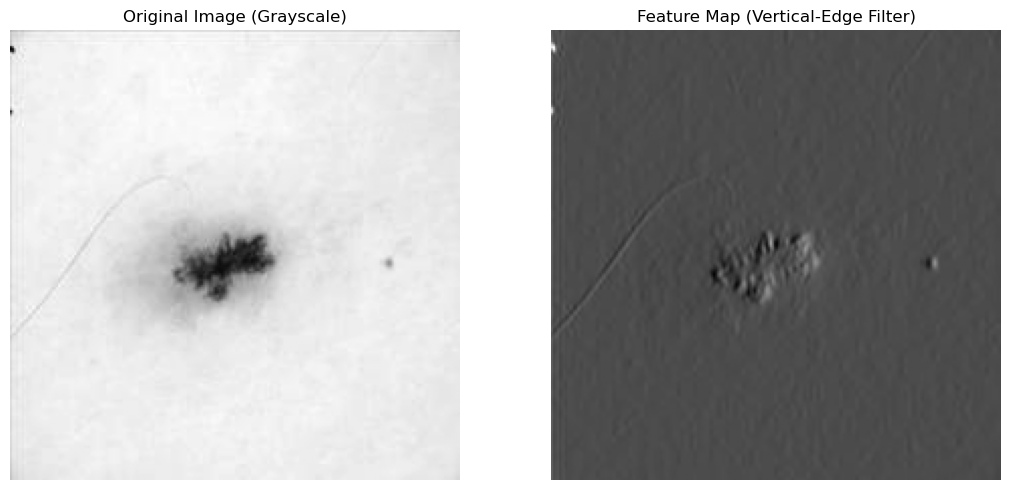

In [8]:
grayscale_image = np.array(sample_image.convert("L"), dtype=np.float64)
feature_map = convolve2d_valid(grayscale_image, vertical_edge_filter)
print("Grayscale image shape:", grayscale_image.shape)
print("Feature map shape    :", feature_map.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(grayscale_image, cmap="gray")
axes[0].set_title("Original Image (Grayscale)")
axes[0].axis("off")
axes[1].imshow(feature_map, cmap="gray")
axes[1].set_title("Feature Map (Vertical-Edge Filter)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

The feature map (right) lights up exactly where the original image has a strong vertical edge &mdash; the filter found that structure automatically, using only 9 numbers.

<a id="section8"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">8. Parameter Sharing &amp; Why Convolution Is Efficient</h2>
<div style="border-left:5px solid #4338CA; background-color:#4338CA14; padding:12px 16px; margin:14px 0; border-radius:6px; color:inherit; line-height:1.65;">
<b style="color:#4338CA;">Definition — Parameter sharing:</b> the same small filter (just 9 numbers above) is reused at every position across the whole image, instead of learning a separate set of weights per pixel location.

 <p>Because the same filter is applied across different spatial locations, it can detect the same pattern in different parts of the image.
</div>



In [9]:
filter_weights = vertical_edge_filter.size
reduction_factor = weights_needed / filter_weights

print(f"Weights needed by the convolution filter : {filter_weights}")
print(f"Weights needed by a comparable dense layer: {weights_needed:,}")
print(f"The filter uses about {reduction_factor:,.0f} times fewer weights.")

Weights needed by the convolution filter : 9
Weights needed by a comparable dense layer: 19,267,584
The filter uses about 2,140,843 times fewer weights.


Because the exact same filter slides across the whole image, a CNN needs far fewer weights than a dense layer looking at the same picture &mdash; this is the main reason CNNs are practical on images.

<a id="section9"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">9. Feature Hierarchy</h2>
One filter only detects one simple pattern. A real CNN stacks many filters across many layers, and the patterns get more complex with depth:

<div style="border:1px solid #CBD5E1; border-radius:8px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; font-size:14.5px;">
<tr style="background-color:#1E40AF; color:#FFFFFF;"><th style="padding:10px; text-align:left;">Layer depth</th><th style="padding:10px; text-align:left;">Typically detects</th></tr>
<tr style="background-color:#FFFFFF;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Early layers</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Simple patterns: edges, corners, blobs of color</td></tr>
<tr style="background-color:#F8FAFC;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Middle layers</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Combinations: textures, simple shapes</td></tr>
<tr style="background-color:#FFFFFF;"><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Deep layers</td><td style="padding:9px; border-top:1px solid #E2E8F0; color:#0F172A;">Whole objects or parts: an eye, a wheel, a lesion shape</td></tr>
</table></div>

Nobody designs these by hand &mdash; the network learns them from data during training, the same way it learns weights in a dense network.

<p style="text-align:right; margin:4px 0 0 0;"><a href="#toc" style="color:#1E40AF; font-size:13px; text-decoration:none;">&uarr; Back to Table of Contents</a></p>

<a id="section10"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">10. Architecture Decision</h2>
<b>Data type:</b> Images

<b>Selected architecture:</b> Convolutional Neural Network (CNN)

<b>Reason:</b> the project works with images, where spatial relationships and local visual patterns matter. CNNs use local filters and shared weights, which fits this task better than a fully connected network.

In [10]:
project_data_type = "images"

architecture_decision = {
    "images": "Convolutional Neural Network (CNN)",
    "text_or_sequence": "RNN / LSTM / Transformer",
    "tabular": "Dense network",
}

chosen_architecture = architecture_decision[project_data_type]
print(f"Project data type  : {project_data_type}")
print(f"Architecture chosen: {chosen_architecture}")

Project data type  : images
Architecture chosen: Convolutional Neural Network (CNN)


<a id="section11"></a>
<h2 style="color:#FFFFFF; background-color:#1E40AF; font-weight:700; margin-top:34px; padding:10px 16px; border-radius:8px; font-size:19px;">11. Summary</h2>
A quick recap of the numbers from this notebook, computed directly from the variables above:

In [11]:
print(f"Image dimensions        : {image_height} x {image_width} x {image_channels}")
print(f"Feature map dimensions  : {feature_map.shape[0]} x {feature_map.shape[1]}")
print(f"Dense-layer weight count: {weights_needed:,} (128-neuron first layer)")
print(f"Filter weight count     : {filter_weights}")
print(f"Weight reduction        : about {reduction_factor:,.0f}x fewer weights")
print(f"Selected architecture   : {chosen_architecture}")

Image dimensions        : 224 x 224 x 3
Feature map dimensions  : 222 x 222
Dense-layer weight count: 19,267,584 (128-neuron first layer)
Filter weight count     : 9
Weight reduction        : about 2,140,843x fewer weights
Selected architecture   : Convolutional Neural Network (CNN)


- Images contain many spatially related pixel values.
- Dense layers become inefficient when applied directly to images.
- Convolution applies small filters to local image regions.
- A feature map shows where a filter responds strongly.
- Parameter sharing lets the same filter be reused across the image.
- CNN is the selected architecture for this project.

Day 2 builds a full CNN in Keras with convolution, pooling, and dense layers, adds data augmentation, and applies transfer learning from a pre-trained model.